In [17]:
import numpy as np
import matplotlib.pyplot as plt


In [18]:

# ── Telescope & beam constants (same as your notebook) ──────────────────────
D      = 20.0
c      = 3.0e8
nu_cen = 600e6
nu_min = 400e6
nu_max = 800e6
BW     = 400e6
Trec, Tsky = 22, 3
Np     = 2
t_obs  = 1e-3
k      = 1.38e-23
G0     = np.pi * D**2 / 4 * 0.6 / 2.0 / k * 1e-26
SNR_threshold = 10

_COEFF = (D**2 * 2.355**2) / (2 * 1.22**2 * c**2)
theta_hp = np.sqrt(np.log(2) / (_COEFF * nu_cen**2))
theta_max = 4.0 * theta_hp   # draw out to 4× half-power radius

S_CONST = G0 * np.sqrt(BW * t_obs * Np) / (Trec + Tsky)

# ── Simulation ───────────────────────────────────────────────────────────────
N_frb   = 200_000
rng     = np.random.default_rng(42)

# Uniform sky → p(θ) ∝ θ
theta   = theta_max * np.sqrt(rng.random(N_frb))

# Delta-function spectrum: random peak frequency per FRB
nu_peak = rng.uniform(nu_min, nu_max, N_frb)

# Beam gain at each FRB's peak frequency and position
G = G0 * np.exp(-_COEFF * theta**2 * nu_peak**2)

# Flat distribution of intrinsic flux densities (log-spaced)
S_true  = 10 ** rng.uniform(-1, 2, N_frb)   # Jy, log-flat (agnostic about lum function)

# Observed SNR
snr = S_true * G * np.sqrt(BW * t_obs * Np) / (Trec + Tsky)

detected = snr > SNR_threshold

# ── Count detections in flux bins ────────────────────────────────────────────
S_bins  = np.logspace(-3, 4, 40)
S_mid   = 0.5 * (S_bins[:-1] + S_bins[1:])

n_generated, _ = np.histogram(S_true,          bins=S_bins)
n_detected,  _ = np.histogram(S_true[detected], bins=S_bins)
n_detected_frb = np.sum(n_detected)
print (n_detected_frb)
efficiency = np.where(n_generated > 0, n_detected / n_generated, 0)


14993


/tmp/ipykernel_1122689/1975415926.py:50: RuntimeWarning: invalid value encountered in divide
  efficiency = np.where(n_generated > 0, n_detected / n_generated, 0)


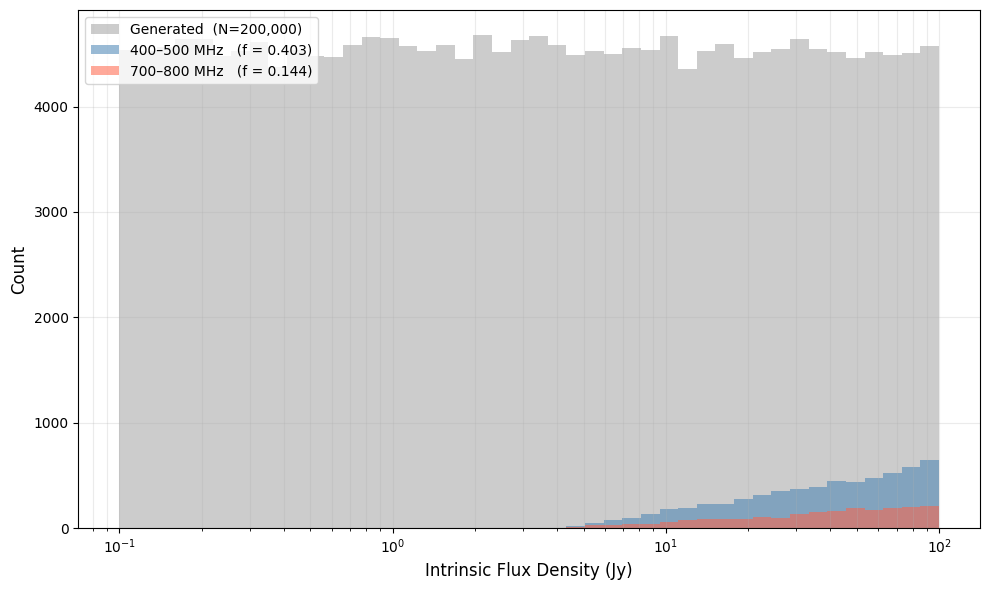

In [19]:
bands = [
    (400e6, 500e6, '400–500 MHz', 'steelblue'),
    (700e6, 800e6, '700–800 MHz', 'tomato'),
]
 
# Full-band for the "all generated" histogram
S_bins = np.logspace(-1, 2, 45)
fig, ax = plt.subplots(figsize=(10, 6))
 
# Generated FRBs (all, frequency-agnostic) — same for every band
n_gen, _ = np.histogram(S_true, bins=S_bins)
ax.stairs(n_gen, S_bins, color='grey', alpha=0.4, fill=True, label=f'Generated  (N={N_frb:,})')
 
# Detected per band
for nu_lo, nu_hi, label, color in bands:
    mask_band = (nu_peak >= nu_lo) & (nu_peak < nu_hi)
 
    n_band_gen = np.sum(mask_band)
    n_band_det = np.sum(mask_band & detected)
    frac = n_band_det / n_detected_frb if n_band_gen > 0 else 0
 
    S_det_band = S_true[mask_band & detected]
    n_det_hist, _ = np.histogram(S_det_band, bins=S_bins)
 
    ax.stairs(n_det_hist, S_bins, color=color, linewidth=2,
              fill=True, alpha=0.55,
              label=f'{label}   (f = {frac:.3f})')
 
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Intrinsic Flux Density (Jy)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
# ax.set_title('FRB Detection: generated vs detected by frequency band\n'
#              '(delta-function spectrum, Gaussian beam, log-flat flux)', fontsize=12)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, which='both', alpha=0.25)
 
plt.tight_layout()
